# Practica Guiada 05



Integrantes:
- Edison Jean Franco Coaguila Fuentes
- Joe Maicol Turpo Queque
- Alfredo Mauricio Aragon Ovalle

# Importación de librerías
Se importan las librerías necesarias para el análisis y visualización de datos.

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.manifold import MDS
from category_encoders import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split

In [2]:
path = kagglehub.dataset_download("cherngs/heart-disease-cleveland-uci")

In [3]:
print(path)

C:\Users\Administrador\.cache\kagglehub\datasets\cherngs\heart-disease-cleveland-uci\versions\1


# Carga de datos


In [4]:
data = pd.read_csv(path+"/heart_cleveland_upload.csv")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [6]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


# Preprocesamiento

In [7]:
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [8]:
data.dropna(inplace=True)

In [9]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.drop(['condition']).tolist()
cat_cols = data.select_dtypes(include=['object']).columns.tolist()


In [10]:
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Modelos de clasificación

In [11]:
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=300, class_weight=None))
])

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42))
])

pipe_nb = Pipeline([
    ("preprocessor", preprocessor),
    ("nb", GaussianNB())
])

pipe_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42))
])

pipelines = {
    "LR": pipe_lr,
    "RF": pipe_rf,
    "NB": pipe_nb,
    "GB": pipe_gb
}

# Evaluación

In [12]:
def eval_metrics(y_true, y_pred):    
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return accuracy, recall, f1

In [13]:
X = data.drop(['condition'], axis=1)
y = data['condition']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [15]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    metrics = eval_metrics(y_test, y_pred)
    print(f"{name} - Accuracy: {metrics[0]:.4f}, Recall: {metrics[1]:.4f}, F1 Score: {metrics[2]:.4f}")


LR - Accuracy: 0.8667, Recall: 0.7429, F1 Score: 0.8387
RF - Accuracy: 0.8533, Recall: 0.7429, F1 Score: 0.8254
NB - Accuracy: 0.8800, Recall: 0.7429, F1 Score: 0.8525
GB - Accuracy: 0.8400, Recall: 0.8000, F1 Score: 0.8235


# Comparación y análisis

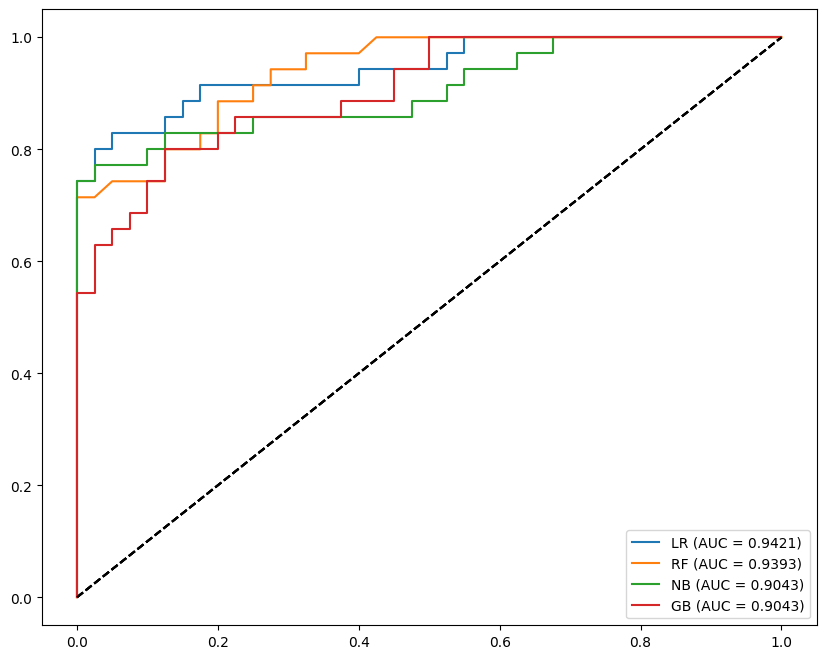

In [16]:
# Curvas ROC y AUC para cada modelo
plt.figure(figsize=(10, 8))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
    plt.legend(loc='lower right')
    plt.plot([0, 1], [0, 1], 'k--')


## Conclusion:
 Dado la naturaleza médica de la situación de detectar enfermedades cardiacas que aborda este dataset, lo más importante seria no perder pacientes enfermos por lo tanto, la metrica de mayor prioridad seria el Recall. Dicho esto, Gradient Boosting (GB) seria el más adecuado, ya que tiene el mejor recall de los 4 con un 0.9032. Sin embargo, Logistic Regression (LR) seria una excelente opción, ya que presenta un buen balance entre AUC y F1 pero con un recall mas bajo que el Gradient Boosting.